## Day4-Model building and evaluation

#### Model Building — Classification
##### A classification model to predict whether a person is at risk of heart attack.
#### Model:Logistic Regression-
##### Suitable for binary classification problems
##### Simple and interpretable
##### Provides probability-based predictions
##### The target variable is:
##### Heart Attack Risk (Binary) (0 = No Risk, 1 = Risk)

#### Prepare Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("day3_ML_output.csv")
df.head()

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Blood sugar,CK-MB,Troponin,Heart Attack Risk (Text),Gender,Systolic blood pressure,Diastolic blood pressure,Health_Risk_Score,Lifestyle_Ratio,Stress_Heart_Interaction
0,0.595506,0.314286,0.047663,0.0,0.0,1.0,0.0,0.0,0.208326,0,...,0.227018,0.048229,0.036512,0,3,0.600000,0.534884,1.0,0.134297,0.428964
1,0.595506,0.096429,0.047663,1.0,1.0,1.0,1.0,1.0,0.752420,1,...,0.227018,0.048229,0.036512,0,3,0.574194,0.569767,4.0,0.439809,0.142988
2,0.595506,0.189286,0.047663,0.0,0.0,1.0,0.0,1.0,0.200998,2,...,0.227018,0.048229,0.036512,0,3,0.187097,0.674419,1.0,0.152216,0.428964
3,0.078652,0.960714,0.071494,1.0,1.0,1.0,1.0,1.0,0.090557,2,...,0.227018,0.048229,0.036512,0,3,0.645161,0.593023,4.0,0.064062,0.071494
4,0.078652,0.792857,0.071494,1.0,0.0,1.0,1.0,0.0,0.601030,2,...,0.227018,0.048229,0.036512,0,3,0.251613,0.383721,3.0,0.457048,0.285976


#### Prepare Data & Train Logistic Regression Model

In [6]:
import pandas as pd

# clean column names (safe step)
df.columns=df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

# target
target="Heart_Attack_Risk_Binary"

# features
X=df.drop(columns=[target])
y=df[target]

# encoding
X=pd.get_dummies(X, drop_first=True)

# remone any remaining NaN
X=X.fillna(0)

# check missing values
print("Remaining NaN:", X.isnull().sum().sum())

# split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

Remaining NaN: 0


##### After preprocessing the dataset, all missing values were successfully handled by replacing them with 0. The output “Remaining NaN: 0” confirms that there are no null values present in the feature set. This ensures that the dataset is clean and suitable for machine learning models, as algorithms like Logistic Regression cannot process missing values. Proper handling of missing data improves model stability and prevents errors during training and prediction.

In [7]:
print(X.isnull().sum())

Age                                0
Cholesterol                        0
Heart_rate                         0
Diabetes                           0
Family_History                     0
Smoking                            0
Obesity                            0
Alcohol_Consumption                0
Exercise_Hours_Per_Week            0
Diet                               0
Previous_Heart_Problems            0
Medication_Use                     0
Stress_Level                       0
Sedentary_Hours_Per_Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical_Activity_Days_Per_Week    0
Sleep_Hours_Per_Day                0
Blood_sugar                        0
CK-MB                              0
Troponin                           0
Heart_Attack_Risk_Text             0
Gender                             0
Systolic_blood_pressure            0
Diastolic_blood_pressure           0
Health_Risk_Score                  0
L

In [8]:
print(X.dtypes)

Age                                float64
Cholesterol                        float64
Heart_rate                         float64
Diabetes                           float64
Family_History                     float64
Smoking                            float64
Obesity                            float64
Alcohol_Consumption                float64
Exercise_Hours_Per_Week            float64
Diet                                 int64
Previous_Heart_Problems            float64
Medication_Use                     float64
Stress_Level                       float64
Sedentary_Hours_Per_Day            float64
Income                             float64
BMI                                float64
Triglycerides                      float64
Physical_Activity_Days_Per_Week    float64
Sleep_Hours_Per_Day                float64
Blood_sugar                        float64
CK-MB                              float64
Troponin                           float64
Heart_Attack_Risk_Text               int64
Gender     

### Handling Missing Values
##### The dataset initially contained missing values (NaN), which caused errors during model training.
##### To resolve this:Missing values were replaced using zero (`fillna(0)`).
##### After preprocessing:The dataset contained **0 missing values**, confirming successful data cleaning.
##### This step ensured the data was suitable for training the Logistic Regression model without errors.


### Evaluation Metrics

In [9]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6664940445365096
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[1287    0]
 [ 644    0]]


C:\Users\sana_anas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Accuracy:
##### measure how many predictions are correct out of all prediction.
#### Precision:
##### how many predictions are positive in actually corrected.
#### Recall:
##### Measures how well the model identifies from actual positive cases

### Confusion Matrix Visualization

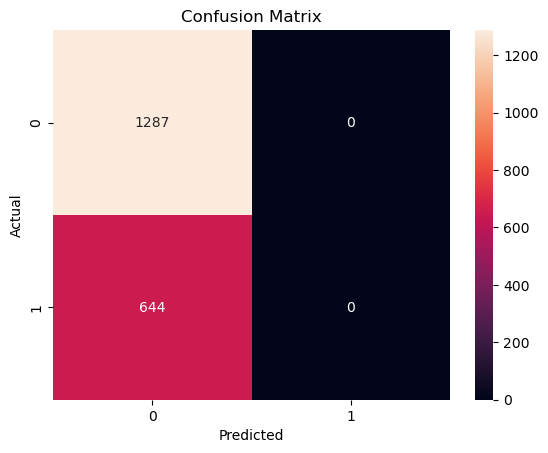

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### True Positives:Bottom Right (0),Actual = 1,Predicted = 1 that Model failed to detect ANY risk cases.
##### True Negatives:Top Left (1287),Actual = 0,Predicted = 0,Correct prediction (No heart attack - predicted no risk)
##### False Positives:Top Right (0),Actual = 0,Predicted = 1,Model did NOT wrongly predict risk.
##### False Negatives:Bottom Left (644),Actual = 1,Predicted = 0,VERY BAD,These are real risk patients but model said NO risk
#### Interpretation:
##### High accuracy indicates good overall performance
##### Precision and recall help understand model reliability in detecting heart attack risk
##### Confusion matrix provides detailed insight into prediction errors

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5743138270326256


#### ≈ 57.4% accuracy (Out of 100 predictions:About 57 are correct,About 43 are wrong).
##### A Decision Tree model was also implemented to compare performance.
##### It can capture non-linear relationships
##### May perform better when features are complex
##### Comparison with Logistic Regression helps in selecting the best model.

#### Conclusion:
##### While the Decision Tree can capture non-linear relationships, the overall performance remains limited due to data quality and feature strength.
##### Further improvement can be achieved through better feature engineering, feature selection, or trying more advanced models.
#### Future Improvements:
##### Use feature importance to identify strong predictors
##### Try ensemble models (Random Forest)
##### Apply feature scaling and transformation

In [83]:
df.to_csv("day4_ML_output.csv",index=False)